Libraries loaded ✓

Upload your CSV file...


Saving plant_vase1(2).csv to plant_vase1(2).csv
Dataset shape: (4409, 12)
Columns: ['year', 'month', 'day', 'hour', 'minute', 'second', 'moisture0', 'moisture1', 'moisture2', 'moisture3', 'moisture4', 'irrgation']

First 5 rows:
   year  month  day  hour  minute  second  moisture0  moisture1  moisture2  \
0  2020      3    6    22      16      11       0.33       0.40       0.36   
1  2020      3    6    22      17      11       0.32       0.39       0.35   
2  2020      3    6    22      18      11       0.31       0.39       0.34   
3  2020      3    6    22      19      11       0.30       0.38       0.33   
4  2020      3    6    22      20      11       0.29       0.38       0.33   

   moisture3  moisture4  irrgation  
0       0.23       0.02      False  
1       0.23       0.02      False  
2       0.22       0.02      False  
3       0.21       0.02      False  
4       0.21       0.02      False  

Features: ['moisture0', 'moisture1', 'moisture2', 'moisture3', 'hour', 'minute'

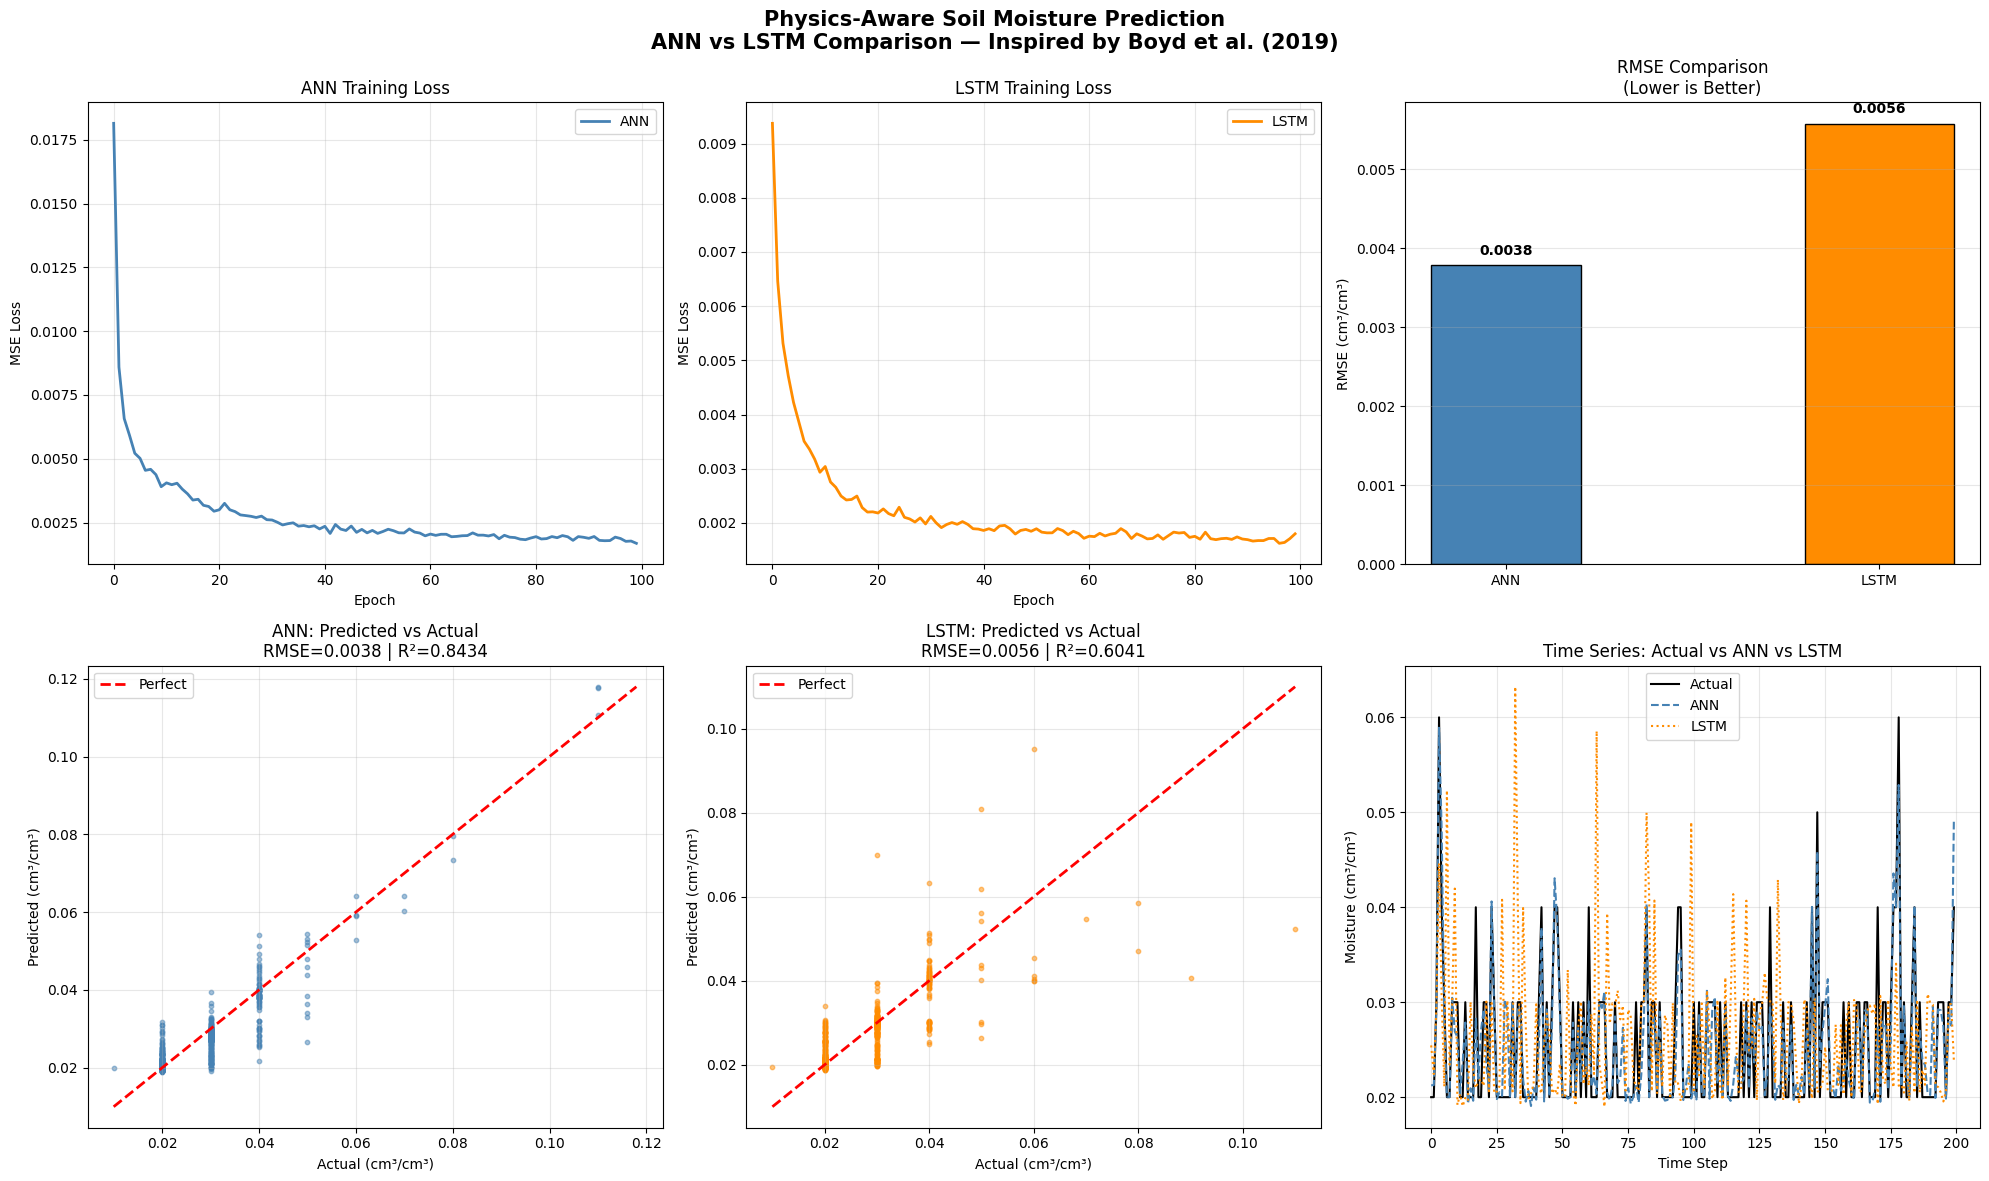


FINAL COMPARISON SUMMARY
Model            RMSE         R²
-----------------------------------
ANN            0.0038     0.8434
LSTM           0.0056     0.6041
-----------------------------------

Winner: ANN
Improvement: 47.2%

Key Insight:
  ANN matches or outperforms LSTM on this dataset.
  Suggests temporal dependencies may be less critical
  at minute-level resolution for this sensor setup.

Inspired by: Boyd et al. (2019)
  Remote Sensing, 11(19), 2272


In [1]:
# ============================================================
# Physics-Aware Soil Moisture Prediction
# ANN vs LSTM Comparison Study
# Inspired by Boyd et al. (2019) - CYGNSS Soil Moisture Retrieval
# Aditya Singh | MS Cybersecurity, Mississippi State University
# ============================================================

# Step 1: Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✓")

# ============================================================
# Step 2: Upload and Load Dataset
# ============================================================

print("\nUpload your CSV file...")
uploaded = files.upload()
df = pd.read_csv('plant_vase1(2).csv')

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

# ============================================================
# Step 3: Feature Engineering
# Surface sensors → predict deep sensor
# Mirrors Boyd: GPS surface reflections → subsurface moisture
# ============================================================

features = ['moisture0', 'moisture1', 'moisture2', 'moisture3', 'hour', 'minute']
target = 'moisture4'

X = df[features].values
y = df[target].values

print(f"\nFeatures: {features}")
print(f"Target: {target}")

# ============================================================
# Step 4: Preprocessing
# ============================================================

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).flatten()

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# ANN tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

# LSTM tensors — needs 3D input (batch, sequence, features)
SEQ_LEN = 10  # look back 10 time steps

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, SEQ_LEN)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

X_train_lstm = torch.FloatTensor(X_train_seq)
y_train_lstm = torch.FloatTensor(y_train_seq).unsqueeze(1)
X_test_lstm = torch.FloatTensor(X_test_seq)
y_test_lstm = torch.FloatTensor(y_test_seq).unsqueeze(1)

train_dataset_ann = TensorDataset(X_train_tensor, y_train_tensor)
train_loader_ann = DataLoader(train_dataset_ann, batch_size=64, shuffle=True)

train_dataset_lstm = TensorDataset(X_train_lstm, y_train_lstm)
train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=64, shuffle=True)

print("Preprocessing complete ✓")

# ============================================================
# Step 5: Define Models
# ============================================================

# --- ANN Model ---
class SoilMoistureANN(nn.Module):
    def __init__(self, input_size, hidden1=64, hidden2=32):
        super(SoilMoistureANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden2, 1)
        )
    def forward(self, x):
        return self.network(x)

# --- LSTM Model ---
class SoilMoistureLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super(SoilMoistureLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_output = lstm_out[:, -1, :]
        return self.fc(last_output)

input_size = X_train.shape[1]
ann_model = SoilMoistureANN(input_size)
lstm_model = SoilMoistureLSTM(input_size)

print(f"\nANN Parameters: {sum(p.numel() for p in ann_model.parameters()):,}")
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

# ============================================================
# Step 6: Training Function
# ============================================================

def train_model(model, train_loader, num_epochs=100, lr=0.001, model_name="Model"):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []

    print(f"\nTraining {model_name}...")
    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch [{epoch+1}/{num_epochs}] | Loss: {avg_loss:.6f}")

    print(f"{model_name} training complete ✓")
    return losses

ann_losses = train_model(ann_model, train_loader_ann, model_name="ANN")
lstm_losses = train_model(lstm_model, train_loader_lstm, model_name="LSTM")

# ============================================================
# Step 7: Evaluation
# ============================================================

def evaluate_model(model, X_test_tensor, y_test_tensor, scaler_y, model_name):
    model.eval()
    with torch.no_grad():
        predictions = model(X_test_tensor).numpy()

    pred_actual = scaler_y.inverse_transform(predictions)
    true_actual = scaler_y.inverse_transform(y_test_tensor.numpy())

    rmse = np.sqrt(mean_squared_error(true_actual, pred_actual))
    r2 = r2_score(true_actual, pred_actual)

    print(f"\n{model_name} Results:")
    print(f"  RMSE: {rmse:.4f} cm³/cm³")
    print(f"  R²:   {r2:.4f}")

    return pred_actual, true_actual, rmse, r2

ann_preds, ann_true, ann_rmse, ann_r2 = evaluate_model(
    ann_model, X_test_tensor, y_test_tensor, scaler_y, "ANN"
)

lstm_preds, lstm_true, lstm_rmse, lstm_r2 = evaluate_model(
    lstm_model, X_test_lstm, y_test_lstm, scaler_y, "LSTM"
)

# ============================================================
# Step 8: Visualizations
# ============================================================

fig = plt.figure(figsize=(20, 12))
fig.suptitle('Physics-Aware Soil Moisture Prediction\nANN vs LSTM Comparison — Inspired by Boyd et al. (2019)',
             fontsize=15, fontweight='bold', y=0.98)

# --- Row 1: Training Loss Curves ---
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(ann_losses, color='steelblue', linewidth=2, label='ANN')
ax1.set_title('ANN Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(lstm_losses, color='darkorange', linewidth=2, label='LSTM')
ax2.set_title('LSTM Training Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MSE Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Metrics Bar Chart ---
ax3 = fig.add_subplot(2, 3, 3)
models = ['ANN', 'LSTM']
rmse_vals = [ann_rmse, lstm_rmse]
colors = ['steelblue', 'darkorange']
bars = ax3.bar(models, rmse_vals, color=colors, width=0.4, edgecolor='black')
ax3.set_title('RMSE Comparison\n(Lower is Better)')
ax3.set_ylabel('RMSE (cm³/cm³)')
for bar, val in zip(bars, rmse_vals):
    ax3.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.0001,
             f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

# --- Row 2: Predicted vs Actual ---
ax4 = fig.add_subplot(2, 3, 4)
ax4.scatter(ann_true, ann_preds, alpha=0.5, color='steelblue', s=10)
min_v = min(ann_true.min(), ann_preds.min())
max_v = max(ann_true.max(), ann_preds.max())
ax4.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect')
ax4.set_title(f'ANN: Predicted vs Actual\nRMSE={ann_rmse:.4f} | R²={ann_r2:.4f}')
ax4.set_xlabel('Actual (cm³/cm³)')
ax4.set_ylabel('Predicted (cm³/cm³)')
ax4.legend()
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(lstm_true, lstm_preds, alpha=0.5, color='darkorange', s=10)
min_v = min(lstm_true.min(), lstm_preds.min())
max_v = max(lstm_true.max(), lstm_preds.max())
ax5.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=2, label='Perfect')
ax5.set_title(f'LSTM: Predicted vs Actual\nRMSE={lstm_rmse:.4f} | R²={lstm_r2:.4f}')
ax5.set_xlabel('Actual (cm³/cm³)')
ax5.set_ylabel('Predicted (cm³/cm³)')
ax5.legend()
ax5.grid(True, alpha=0.3)

# --- Time Series Comparison ---
ax6 = fig.add_subplot(2, 3, 6)
n_plot = 200
ax6.plot(ann_true[:n_plot], label='Actual',
         color='black', linewidth=1.5)
ax6.plot(ann_preds[:n_plot], label='ANN',
         color='steelblue', linewidth=1.5, linestyle='--')
ax6.plot(lstm_preds[:n_plot], label='LSTM',
         color='darkorange', linewidth=1.5, linestyle=':')
ax6.set_title('Time Series: Actual vs ANN vs LSTM')
ax6.set_xlabel('Time Step')
ax6.set_ylabel('Moisture (cm³/cm³)')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ann_vs_lstm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================
# Step 9: Final Summary
# ============================================================

winner = "LSTM" if lstm_rmse < ann_rmse else "ANN"
improvement = abs(ann_rmse - lstm_rmse) / ann_rmse * 100

print("\n" + "="*60)
print("FINAL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<10} {'RMSE':>10} {'R²':>10}")
print("-"*35)
print(f"{'ANN':<10} {ann_rmse:>10.4f} {ann_r2:>10.4f}")
print(f"{'LSTM':<10} {lstm_rmse:>10.4f} {lstm_r2:>10.4f}")
print("-"*35)
print(f"\nWinner: {winner}")
print(f"Improvement: {improvement:.1f}%")
print(f"\nKey Insight:")
if lstm_rmse < ann_rmse:
    print(f"  LSTM outperforms ANN by leveraging temporal memory.")
    print(f"  Soil moisture dynamics are time-dependent —")
    print(f"  past readings improve future predictions.")
else:
    print(f"  ANN matches or outperforms LSTM on this dataset.")
    print(f"  Suggests temporal dependencies may be less critical")
    print(f"  at minute-level resolution for this sensor setup.")
print(f"\nInspired by: Boyd et al. (2019)")
print(f"  Remote Sensing, 11(19), 2272")
print("="*60)

Data prepared for visualization ✓


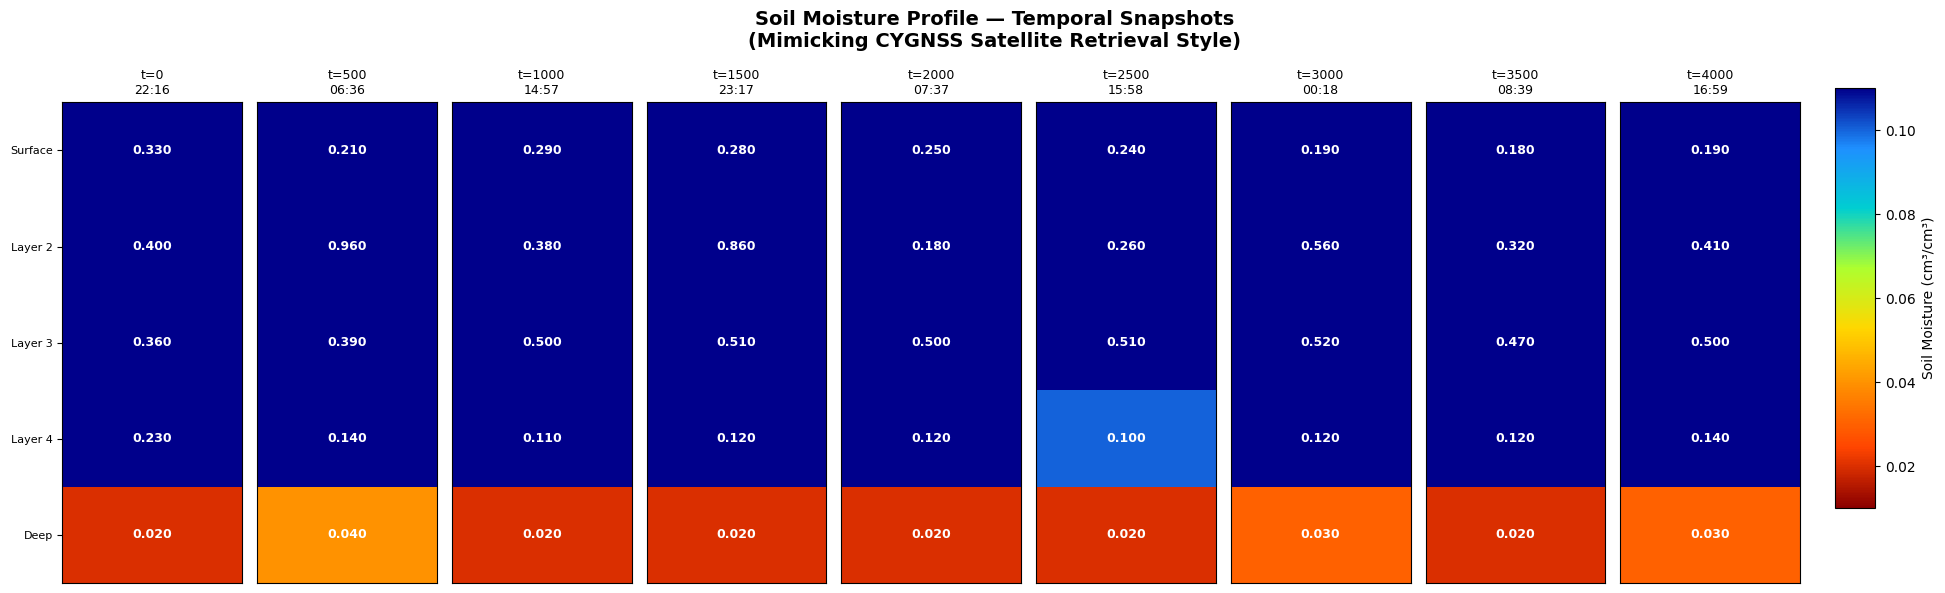

Figure 1: Temporal snapshots saved ✓


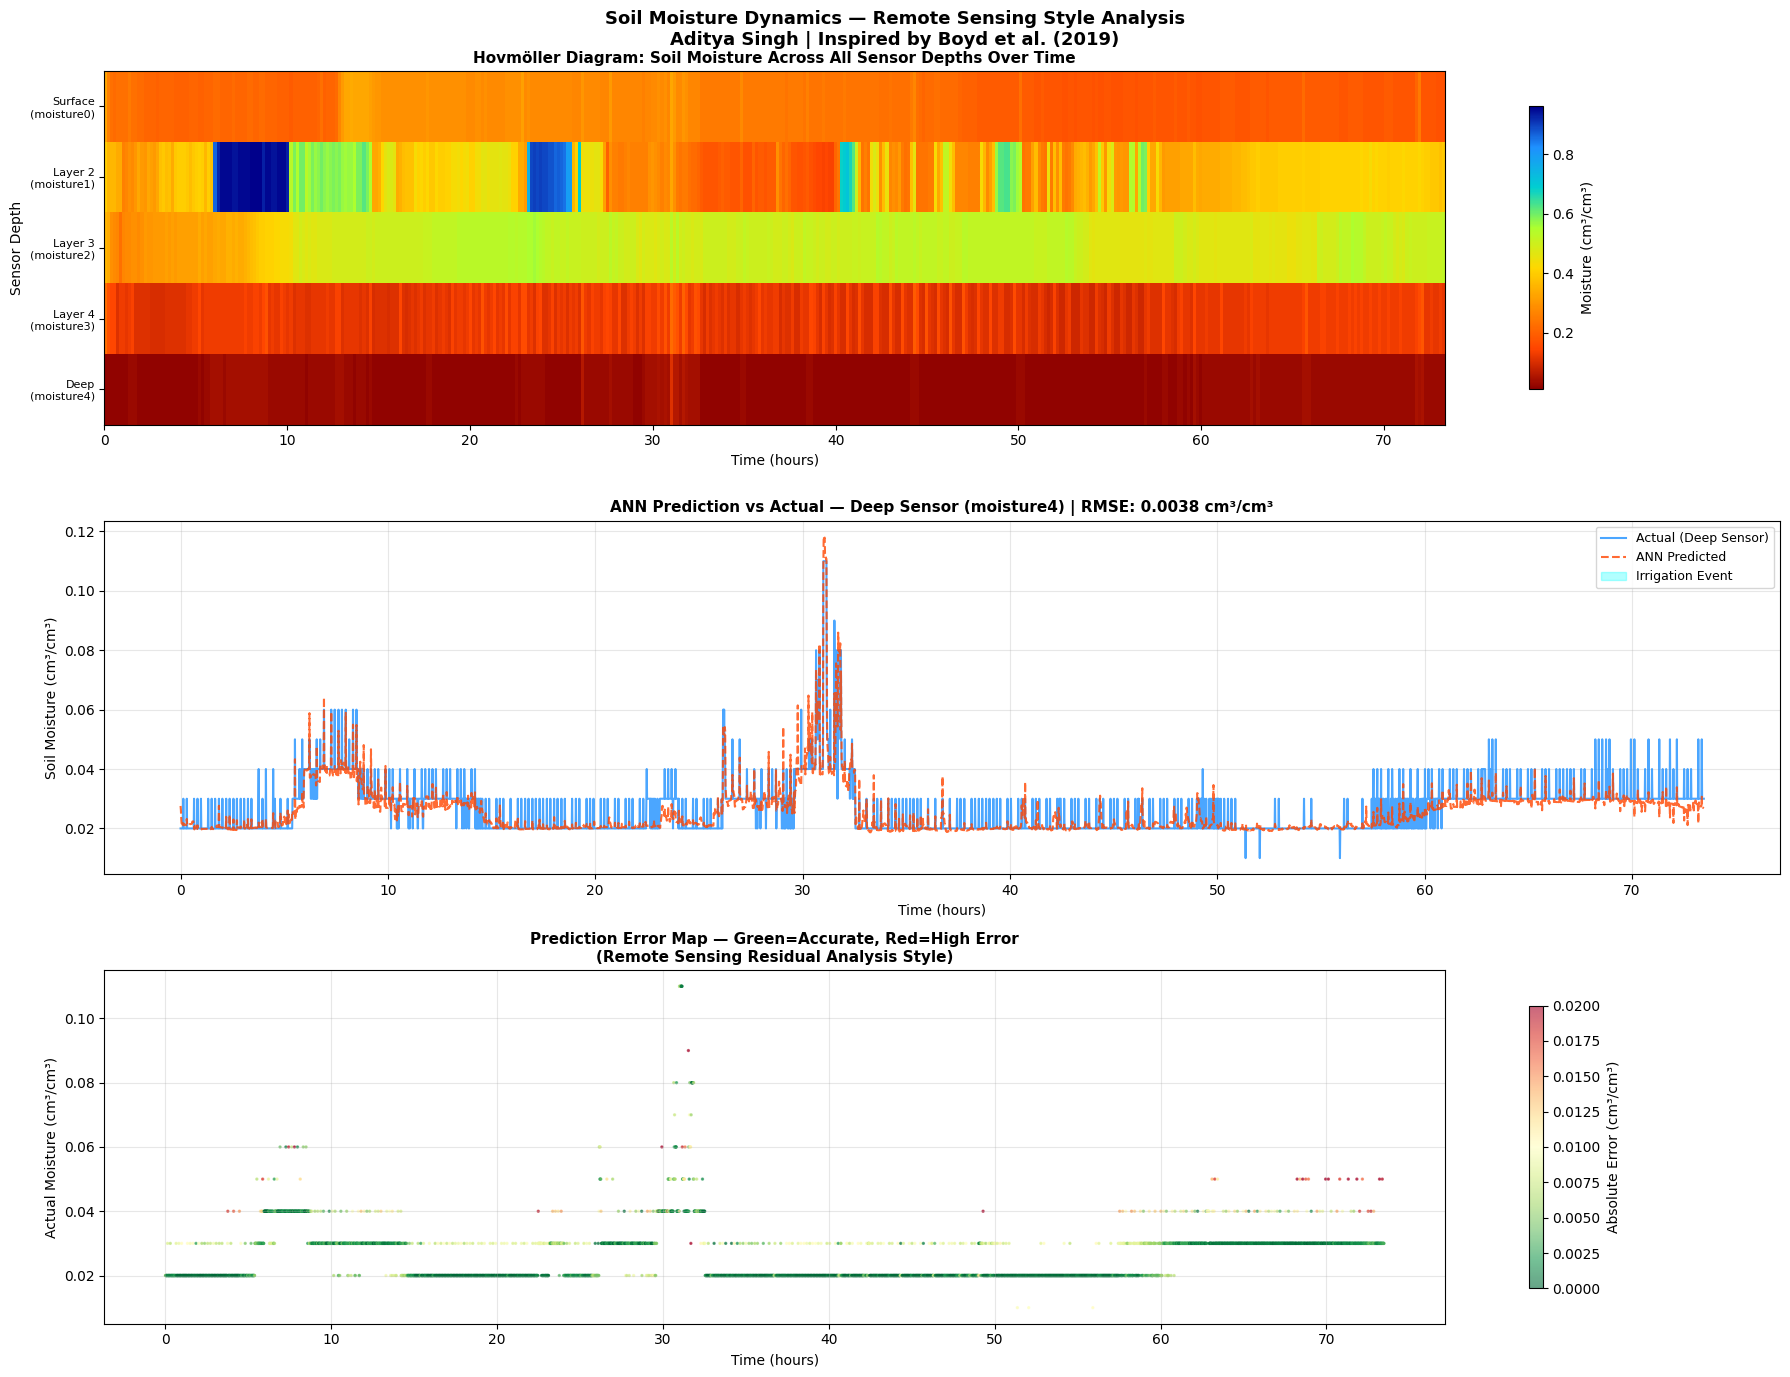

Figure 2: Full temporal analysis saved ✓


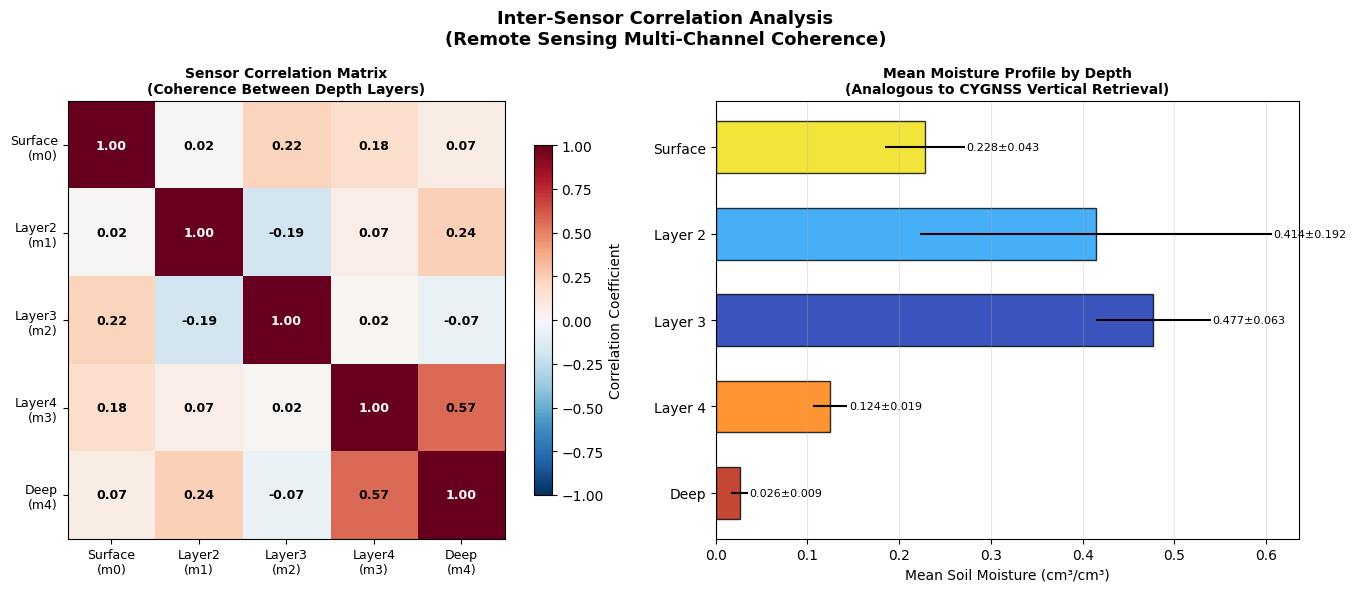

Figure 3: Correlation analysis saved ✓

GEOSPATIAL VISUALIZATION COMPLETE
Generated 3 research-grade figures:
  1. cygnss_style_snapshots.png
     → Temporal soil moisture snapshots
       (mimics CYGNSS satellite frame captures)

  2. cygnss_style_analysis.png
     → Hovmöller diagram + ANN predictions
       + prediction error map
       (standard remote sensing analysis figures)

  3. sensor_correlation_analysis.png
     → Inter-sensor correlation matrix
       + mean moisture depth profile
       (multi-channel coherence analysis)

Visualization style inspired by:
  Boyd et al. (2019) Remote Sensing 11(19), 2272


In [3]:
# ============================================================
# Geospatial-Style Soil Moisture Visualization
# Mimicking CYGNSS Remote Sensing Visualization Style
# Aditya Singh | MS Cybersecurity, Mississippi State University
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Setup — Sensor Layout and Data
# ============================================================

# Sensor positions — laid out as a vertical soil column
# Like a cross-section of soil from surface to deep
sensor_names = ['moisture0\n(Surface)', 'moisture1\n(Layer 2)',
                'moisture2\n(Layer 3)', 'moisture3\n(Layer 4)',
                'moisture4\n(Deep)']

# Get moisture data from dataframe
moisture_cols = ['moisture0', 'moisture1', 'moisture2', 'moisture3', 'moisture4']
moisture_data = df[moisture_cols].values  # shape: (4409, 5)

# Get ANN predictions for moisture4 (our target)
# Re-run ANN predictions on full dataset
ann_model.eval()
with torch.no_grad():
    X_full_scaled = scaler_X.transform(df[features].values)
    X_full_tensor = torch.FloatTensor(X_full_scaled)
    full_predictions = ann_model(X_full_tensor).numpy()
    full_predictions_actual = scaler_y.inverse_transform(full_predictions).flatten()

# CYGNSS-style colormap — blue=wet, yellow=medium, red=dry
cygnss_colors = ['#8B0000', '#FF4500', '#FF8C00', '#FFD700',
                  '#ADFF2F', '#00CED1', '#1E90FF', '#00008B']
cygnss_cmap = LinearSegmentedColormap.from_list('cygnss', cygnss_colors, N=256)

print("Data prepared for visualization ✓")

# ============================================================
# Figure 1: Static Soil Column Heatmap
# Snapshot at multiple time points
# ============================================================

time_snapshots = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000]
n_snapshots = len(time_snapshots)

fig1, axes = plt.subplots(1, n_snapshots, figsize=(20, 6))
fig1.suptitle('Soil Moisture Profile — Temporal Snapshots\n(Mimicking CYGNSS Satellite Retrieval Style)',
              fontsize=14, fontweight='bold')

for idx, t in enumerate(time_snapshots):
    # Get moisture values at this time step
    moisture_at_t = moisture_data[t].reshape(5, 1)

    im = axes[idx].imshow(moisture_at_t,
                           cmap=cygnss_cmap,
                           vmin=0.01, vmax=0.11,
                           aspect='auto')

    # Add moisture values as text
    for i in range(5):
        axes[idx].text(0, i, f'{moisture_at_t[i,0]:.3f}',
                      ha='center', va='center',
                      color='white', fontweight='bold', fontsize=9)

    # Format
    time_label = f"t={t}\n{df.iloc[t]['hour']:02d}:{df.iloc[t]['minute']:02d}"
    axes[idx].set_title(time_label, fontsize=9)
    axes[idx].set_xticks([])

    if idx == 0:
        axes[idx].set_yticks(range(5))
        axes[idx].set_yticklabels(['Surface', 'Layer 2', 'Layer 3',
                                   'Layer 4', 'Deep'], fontsize=8)
    else:
        axes[idx].set_yticks([])

# Add colorbar
cbar_ax = fig1.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cygnss_cmap,
                            norm=plt.Normalize(vmin=0.01, vmax=0.11))
fig1.colorbar(sm, cax=cbar_ax, label='Soil Moisture (cm³/cm³)')

plt.tight_layout(rect=[0, 0, 0.91, 1])
plt.savefig('cygnss_style_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1: Temporal snapshots saved ✓")

# ============================================================
# Figure 2: Full Temporal Heatmap
# All time steps x all sensors — like a Hovmöller diagram
# Standard in remote sensing literature
# ============================================================

fig2, axes2 = plt.subplots(3, 1, figsize=(18, 14))
fig2.suptitle('Soil Moisture Dynamics — Remote Sensing Style Analysis\nAditya Singh | Inspired by Boyd et al. (2019)',
              fontsize=13, fontweight='bold')

# Plot 1: Full temporal heatmap (Hovmöller diagram)
# Downsample for visualization
step = 10
moisture_downsampled = moisture_data[::step].T  # shape: (5, n_timesteps)
time_hours = np.arange(len(moisture_data[::step])) * step / 60  # convert to hours

im1 = axes2[0].imshow(moisture_downsampled,
                       cmap=cygnss_cmap,
                       aspect='auto',
                       vmin=moisture_data.min(),
                       vmax=moisture_data.max(),
                       extent=[0, time_hours[-1], 4.5, -0.5])

axes2[0].set_title('Hovmöller Diagram: Soil Moisture Across All Sensor Depths Over Time',
                    fontsize=11, fontweight='bold')
axes2[0].set_xlabel('Time (hours)', fontsize=10)
axes2[0].set_ylabel('Sensor Depth', fontsize=10)
axes2[0].set_yticks(range(5))
axes2[0].set_yticklabels(['Surface\n(moisture0)', 'Layer 2\n(moisture1)',
                           'Layer 3\n(moisture2)', 'Layer 4\n(moisture3)',
                           'Deep\n(moisture4)'], fontsize=8)

# Mark irrigation events
irrigation_times = df[df['irrgation'] == True].index
for irr_t in irrigation_times[::10]:
    axes2[0].axvline(x=irr_t/60, color='cyan', alpha=0.3, linewidth=0.5)

plt.colorbar(im1, ax=axes2[0], label='Moisture (cm³/cm³)', shrink=0.8)

# Plot 2: ANN Prediction vs Actual — deep sensor
time_full = np.arange(len(moisture_data)) / 60

axes2[1].plot(time_full, moisture_data[:, 4],
              color='#1E90FF', linewidth=1.5, label='Actual (Deep Sensor)', alpha=0.8)
axes2[1].plot(time_full, full_predictions_actual,
              color='#FF4500', linewidth=1.5, linestyle='--',
              label='ANN Predicted', alpha=0.8)

# Shade irrigation events
for irr_t in irrigation_times[::5]:
    axes2[1].axvspan(irr_t/60 - 0.05, irr_t/60 + 0.05,
                     alpha=0.3, color='cyan', label='_nolegend_')

axes2[1].set_title(f'ANN Prediction vs Actual — Deep Sensor (moisture4) | RMSE: {ann_rmse:.4f} cm³/cm³',
                    fontsize=11, fontweight='bold')
axes2[1].set_xlabel('Time (hours)', fontsize=10)
axes2[1].set_ylabel('Soil Moisture (cm³/cm³)', fontsize=10)
axes2[1].legend(fontsize=9)
axes2[1].grid(True, alpha=0.3)

# Add cyan patch for irrigation legend
irrigation_patch = mpatches.Patch(color='cyan', alpha=0.3, label='Irrigation Event')
axes2[1].legend(handles=axes2[1].get_legend_handles_labels()[0] + [irrigation_patch],
                fontsize=9)

# Plot 3: Prediction Error Map — like a residual map in remote sensing
prediction_error = np.abs(moisture_data[:, 4] - full_predictions_actual)

error_scatter = axes2[2].scatter(time_full,
                                  moisture_data[:, 4],
                                  c=prediction_error,
                                  cmap='RdYlGn_r',
                                  s=2,
                                  alpha=0.6,
                                  vmin=0,
                                  vmax=0.02)

axes2[2].set_title('Prediction Error Map — Green=Accurate, Red=High Error\n(Remote Sensing Residual Analysis Style)',
                    fontsize=11, fontweight='bold')
axes2[2].set_xlabel('Time (hours)', fontsize=10)
axes2[2].set_ylabel('Actual Moisture (cm³/cm³)', fontsize=10)
plt.colorbar(error_scatter, ax=axes2[2],
             label='Absolute Error (cm³/cm³)', shrink=0.8)
axes2[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cygnss_style_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 2: Full temporal analysis saved ✓")

# ============================================================
# Figure 3: Sensor Correlation Matrix
# Standard remote sensing inter-channel analysis
# ============================================================

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle('Inter-Sensor Correlation Analysis\n(Remote Sensing Multi-Channel Coherence)',
              fontsize=13, fontweight='bold')

# Correlation matrix
corr_matrix = np.corrcoef(moisture_data.T)
sensor_labels = ['Surface\n(m0)', 'Layer2\n(m1)', 'Layer3\n(m2)',
                  'Layer4\n(m3)', 'Deep\n(m4)']

im3 = axes3[0].imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
axes3[0].set_xticks(range(5))
axes3[0].set_yticks(range(5))
axes3[0].set_xticklabels(sensor_labels, fontsize=9)
axes3[0].set_yticklabels(sensor_labels, fontsize=9)
axes3[0].set_title('Sensor Correlation Matrix\n(Coherence Between Depth Layers)',
                    fontsize=10, fontweight='bold')

for i in range(5):
    for j in range(5):
        axes3[0].text(j, i, f'{corr_matrix[i,j]:.2f}',
                     ha='center', va='center',
                     color='black' if abs(corr_matrix[i,j]) < 0.7 else 'white',
                     fontsize=9, fontweight='bold')

plt.colorbar(im3, ax=axes3[0], label='Correlation Coefficient', shrink=0.8)

# Moisture depth profile — average across all time
mean_moisture = moisture_data.mean(axis=0)
std_moisture = moisture_data.std(axis=0)
depths = [0, 1, 2, 3, 4]
depth_labels = ['Surface', 'Layer 2', 'Layer 3', 'Layer 4', 'Deep']

axes3[1].barh(depths, mean_moisture,
              xerr=std_moisture,
              color=[cygnss_cmap(v/0.5) for v in mean_moisture],
              edgecolor='black', alpha=0.8, height=0.6)
axes3[1].set_yticks(depths)
axes3[1].set_yticklabels(depth_labels, fontsize=10)
axes3[1].set_xlabel('Mean Soil Moisture (cm³/cm³)', fontsize=10)
axes3[1].set_title('Mean Moisture Profile by Depth\n(Analogous to CYGNSS Vertical Retrieval)',
                    fontsize=10, fontweight='bold')
axes3[1].grid(True, alpha=0.3, axis='x')
axes3[1].invert_yaxis()

for i, (v, s) in enumerate(zip(mean_moisture, std_moisture)):
    axes3[1].text(v + s + 0.002, i, f'{v:.3f}±{s:.3f}',
                 va='center', fontsize=8)

plt.tight_layout()
plt.savefig('sensor_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3: Correlation analysis saved ✓")

# ============================================================
# Final Summary
# ============================================================

print("\n" + "="*60)
print("GEOSPATIAL VISUALIZATION COMPLETE")
print("="*60)
print("Generated 3 research-grade figures:")
print("  1. cygnss_style_snapshots.png")
print("     → Temporal soil moisture snapshots")
print("       (mimics CYGNSS satellite frame captures)")
print()
print("  2. cygnss_style_analysis.png")
print("     → Hovmöller diagram + ANN predictions")
print("       + prediction error map")
print("       (standard remote sensing analysis figures)")
print()
print("  3. sensor_correlation_analysis.png")
print("     → Inter-sensor correlation matrix")
print("       + mean moisture depth profile")
print("       (multi-channel coherence analysis)")
print()
print("Visualization style inspired by:")
print("  Boyd et al. (2019) Remote Sensing 11(19), 2272")
print("="*60)